$t = sin(w_1\,t) + sin(w_2\,t)$

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sm

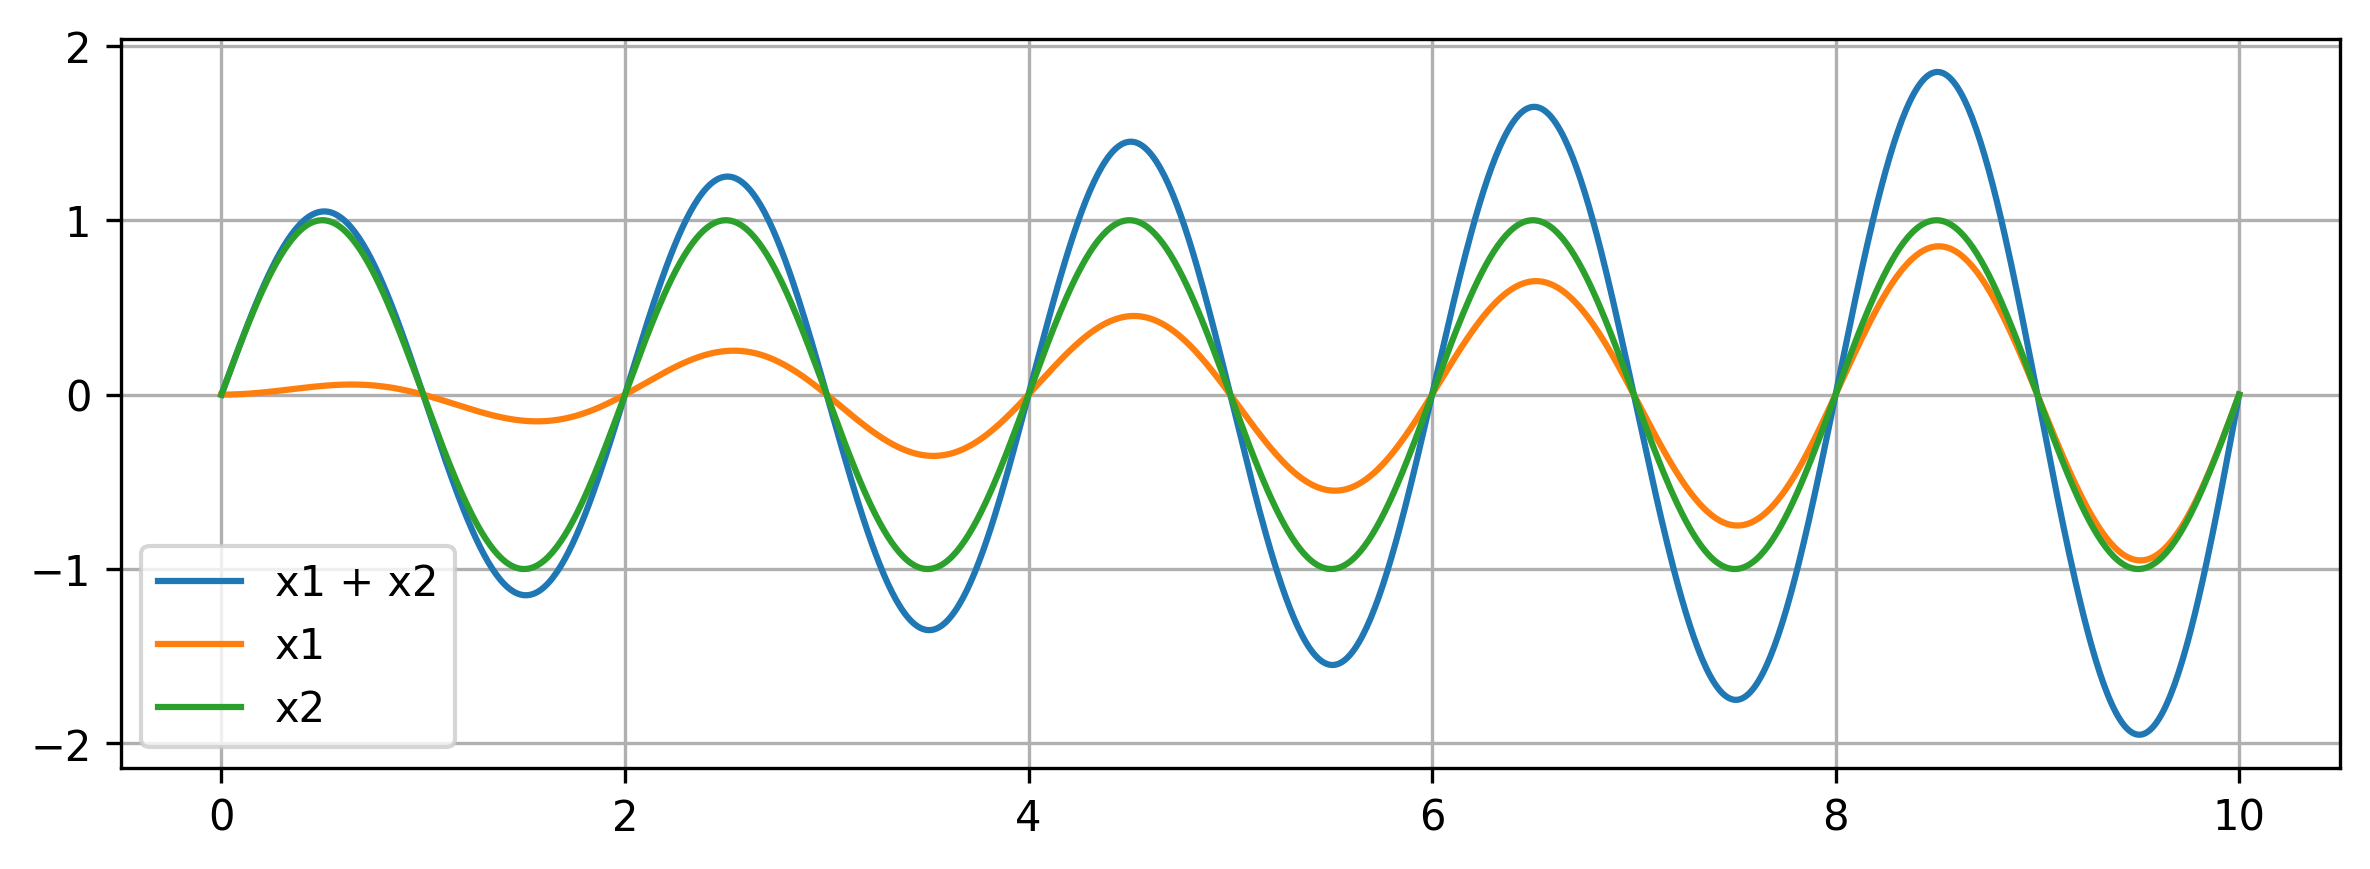

In [52]:
t = np.linspace(0,10,1000)
w1 = 1 * np.pi
p1 = 0
w2 = 1 * np.pi
p2 = 0
x1 = 0.1*t*np.sin(w1 * t + p1)
x2 = np.sin(w2 * t + p2)
x = x1 + x2
fig = plt.figure(figsize=(8,3), dpi=300)
ax = fig.add_subplot(111)
ax.plot(t,x,label="x1 + x2")
ax.plot(t,x1,label="x1")
ax.plot(t,x2,label="x2")
ax.legend()
ax.grid()
fig.tight_layout()
plt.show()

# The method of multiscale

$\dot {\eta} = i \omega \eta + \frac {i \epsilon \delta} {2 \omega} (\eta + \overline \eta)^2 + \frac{i \epsilon^2 \alpha} {2 \omega} (\eta + \overline \eta)^3$

In [53]:
X, a, w, de, eps = sm.symbols("x alpha omega delta epsilon")
T0, T1, T2 = sm.symbols("T0 T1 T2")

def Dt(expr):
    return (
        sm.diff(expr, T0)
        + eps*sm.diff(expr, T1)
        + eps**2*sm.diff(expr, T2)
    )

def trunc(expr, var, order):
    expr = sm.expand(expr)
    return sm.collect(
        sum(expr.coeff(var, n)*var**n for n in range(order)),
        var
    )

x0 = sm.Function("x0")(T0, T1, T2)
x1 = sm.Function("x1")(T0, T1, T2)
x2 = sm.Function("x2")(T0, T1, T2)

f = (
    
    sm.I*w*X
    + eps*de*sm.I/(w*2) * (X + sm.I*X)**2
    + eps**2*a*sm.I/(w*2) * (X + sm.I*X)**3
)

x_series = x0 + eps*x1 + eps**2*x2

f_sub = f.subs(X, x_series)
f_trunc = trunc(f_sub, eps, 3)

dX = Dt(x_series)
dX_trunc = trunc(dX, eps, 3)

expr = sm.collect(sm.expand(dX_trunc - f_trunc), eps)

expr

epsilon**2*(alpha*x0(T0, T1, T2)**3/omega + I*alpha*x0(T0, T1, T2)**3/omega + 2*delta*x0(T0, T1, T2)*x1(T0, T1, T2)/omega - I*omega*x2(T0, T1, T2) + Derivative(x0(T0, T1, T2), T2) + Derivative(x1(T0, T1, T2), T1) + Derivative(x2(T0, T1, T2), T0)) + epsilon*(delta*x0(T0, T1, T2)**2/omega - I*omega*x1(T0, T1, T2) + Derivative(x0(T0, T1, T2), T1) + Derivative(x1(T0, T1, T2), T0)) - I*omega*x0(T0, T1, T2) + Derivative(x0(T0, T1, T2), T0)